      Drug Name  Current Stock  Weekly Sales  Reorder Threshold
0   Amoxicillin             45            20                 30
1     Metformin            100            15                 40
2  Atorvastatin             25            10                 20
3     Ibuprofen             75            25                 30
4    Lisinopril             30            12                 25

Drugs that need reordering:
Empty DataFrame
Columns: [Drug Name, Current Stock, Weekly Sales, Reorder Threshold]
Index: []


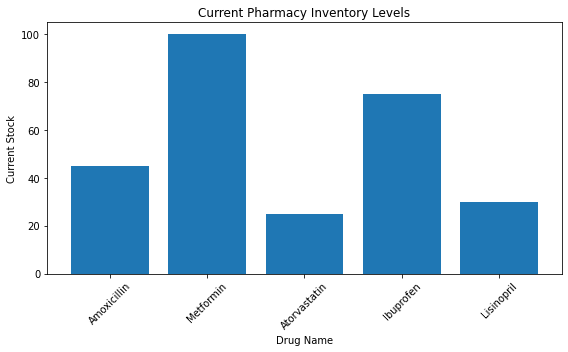

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

# Create a small fake inventory dataset
data = {
    'Drug Name': ['Amoxicillin', 'Metformin', 'Atorvastatin', 'Ibuprofen', 'Lisinopril'],
    'Current Stock': [45, 100, 25, 75, 30],
    'Weekly Sales': [20, 15, 10, 25, 12],
    'Reorder Threshold': [30, 40, 20, 30, 25]
}

# Turn it into a pandas DataFrame
inventory = pd.DataFrame(data)

# Show the data
print(inventory)

# Find which drugs are low on stock
low_stock = inventory[inventory['Current Stock'] <= inventory['Reorder Threshold']]
print("\nDrugs that need reordering:")
print(low_stock)

# Make a simple bar chart of Current Stock
plt.figure(figsize=(8,5))
plt.bar(inventory['Drug Name'], inventory['Current Stock'])
plt.xlabel('Drug Name')
plt.ylabel('Current Stock')
plt.title('Current Pharmacy Inventory Levels')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Days Until Stockout Estimation
We have the weekly sales numbers. Now we can estimate how many days until each drug runs out based on current stock.

In [2]:
# Add a 'Days Until Stockout' column
inventory['Days Until Stockout'] = (inventory['Current Stock'] / inventory['Weekly Sales']) * 7
print(inventory[['Drug Name', 'Days Until Stockout']])


      Drug Name  Days Until Stockout
0   Amoxicillin            15.750000
1     Metformin            46.666667
2  Atorvastatin            17.500000
3     Ibuprofen            21.000000
4    Lisinopril            17.500000


We can predict the needs.

In [3]:
inventory_sorted = inventory.sort_values('Days Until Stockout')
print(inventory_sorted[['Drug Name', 'Days Until Stockout']])


      Drug Name  Days Until Stockout
0   Amoxicillin            15.750000
2  Atorvastatin            17.500000
4    Lisinopril            17.500000
3     Ibuprofen            21.000000
1     Metformin            46.666667


We can color code the low stock in the chart

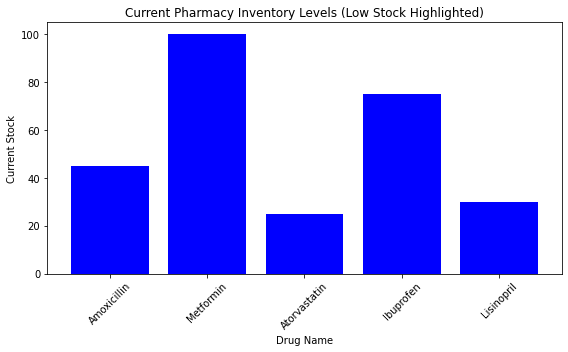

In [4]:
# Color bars based on stock level
colors = ['red' if stock <= threshold else 'blue' 
          for stock, threshold in zip(inventory['Current Stock'], inventory['Reorder Threshold'])]

plt.figure(figsize=(8,5))
plt.bar(inventory['Drug Name'], inventory['Current Stock'], color=colors)
plt.xlabel('Drug Name')
plt.ylabel('Current Stock')
plt.title('Current Pharmacy Inventory Levels (Low Stock Highlighted)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
